# Text Preprocessing - 1
## EDA , Visualization and Multi-Label Analysis

### Importing Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np
from collections import Counter

In [2]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import UpSet, from_indicators

In [3]:
# Text processing
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
# Machine learning & Deep learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

### Load Dataset

In [6]:
#Load dataset files
train_df = pd.read_csv("C:/01_Data/PythonProgram/Toxic_Comment_Classification_PROJECT/train_data/train.csv")
test_df = pd.read_csv("C:/01_Data/PythonProgram/Toxic_Comment_Classification_PROJECT/test_data/test.csv")

### Exploratory Data Analysis (EDA)

In [7]:
train_df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [8]:
test_df

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.
...,...,...
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."


In [9]:
#info
print("DATASET INFO : ")
train_df.info()

DATASET INFO : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [10]:
#columns
print("COLUMN INFO")
columns =train_df.columns.tolist()
print(f"Number of columns : {len(columns)}")
print(f"Column names : {columns}")

COLUMN INFO
Number of columns : 8
Column names : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [11]:
# Identify categorical/text vs numerical columns
text_columns = []
numerical_columns = []
categorical_columns = []

for col in train_df.columns:
    dtype = train_df[col].dtype
    if dtype == 'object':
        text_columns.append(col)
    elif dtype in ['int64', 'float64']:
        numerical_columns.append(col)
    else:
        categorical_columns.append(col)

print(f"Text columns ({len(text_columns)}): {text_columns}")
print(f"Numerical columns ({len(numerical_columns)}): {numerical_columns}")
print(f"Other ({len(categorical_columns)}): {categorical_columns}")

Text columns (2): ['id', 'comment_text']
Numerical columns (6): ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Other (0): []


In [12]:
# Detailed column information including missing values
print("DETAILED COLUMN INFORMATION")
for col in train_df.columns:
    non_null = train_df[col].count()
    null_count = train_df[col].isnull().sum()
    dtype = train_df[col].dtype
    unique_count = train_df[col].nunique() if dtype != 'object' else "N/A (text)"
    print(f"\nColumn: {col}")
    print(f"  Non-null values: {non_null:,}")
    print(f"  Null values: {null_count:,}")

DETAILED COLUMN INFORMATION

Column: id
  Non-null values: 159,571
  Null values: 0

Column: comment_text
  Non-null values: 159,571
  Null values: 0

Column: toxic
  Non-null values: 159,571
  Null values: 0

Column: severe_toxic
  Non-null values: 159,571
  Null values: 0

Column: obscene
  Non-null values: 159,571
  Null values: 0

Column: threat
  Non-null values: 159,571
  Null values: 0

Column: insult
  Non-null values: 159,571
  Null values: 0

Column: identity_hate
  Non-null values: 159,571
  Null values: 0


In [13]:
# TOXICITY ANALYSIS
print("\n\n TOXICITY OVERVIEW")
print("-" * 40)
toxic_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Check if comment has ANY toxic label
has_toxic = train_df[toxic_columns].sum(axis=1) > 0
toxic_count = has_toxic.sum()
non_toxic_count = len(train_df) - toxic_count

print(f" TOTAL COMMENTS: {len(train_df):,}")
print(f" NON-TOXIC: {non_toxic_count:,} ({non_toxic_count/len(train_df)*100:.1f}%)")
print(f" TOXIC: {toxic_count:,} ({toxic_count/len(train_df)*100:.1f}%)")

# Visual bar
print(f"\n DISTRIBUTION VISUAL:")
non_toxic_bars = int(non_toxic_count/len(train_df)*50)
toxic_bars = int(toxic_count/len(train_df)*50)
print("█" * non_toxic_bars + f" Clean ({non_toxic_count/len(train_df)*100:.1f}%)")
print("█" * toxic_bars + f" Toxic ({toxic_count/len(train_df)*100:.1f}%)")



 TOXICITY OVERVIEW
----------------------------------------
 TOTAL COMMENTS: 159,571
 NON-TOXIC: 143,346 (89.8%)
 TOXIC: 16,225 (10.2%)

 DISTRIBUTION VISUAL:
████████████████████████████████████████████ Clean (89.8%)
█████ Toxic (10.2%)


In [14]:
# DETAILED TOXIC CATEGORIES
counts = train_df[toxic_columns].sum()
sorted_counts = counts.sort_values(ascending=False)

print(" TOXIC TYPES (sorted by frequency):")
print("-" * 40)
for category, count in sorted_counts.items():
    pct_total = (count / len(train_df)) * 100
    pct_toxic = (count / toxic_count) * 100 if toxic_count > 0 else 0
    # Visual indicator
    bars = int(count/len(train_df)*60)
    print(f"\n{category:15s}: {count:>6,} comments")
    print(f"  {pct_total:5.1f}% of all comments")
    print(f"  {pct_toxic:5.1f}% of toxic comments")
    print(f"  {'█' * bars}")

 TOXIC TYPES (sorted by frequency):
----------------------------------------

toxic          : 15,294 comments
    9.6% of all comments
   94.3% of toxic comments
  █████

obscene        :  8,449 comments
    5.3% of all comments
   52.1% of toxic comments
  ███

insult         :  7,877 comments
    4.9% of all comments
   48.5% of toxic comments
  ██

severe_toxic   :  1,595 comments
    1.0% of all comments
    9.8% of toxic comments
  

identity_hate  :  1,405 comments
    0.9% of all comments
    8.7% of toxic comments
  

threat         :    478 comments
    0.3% of all comments
    2.9% of toxic comments
  


In [15]:
# TOXICITY ANALYSIS
print("\n\n TOXICITY OVERVIEW")
print("-" * 40)
toxic_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Check if comment has ANY toxic label
has_toxic = train_df[toxic_columns].sum(axis=1) > 0
toxic_count = has_toxic.sum()
non_toxic_count = len(train_df) - toxic_count

print(f" TOTAL COMMENTS: {len(train_df):,}")
print(f" NON-TOXIC: {non_toxic_count:,} ({non_toxic_count/len(train_df)*100:.1f}%)")
print(f" TOXIC: {toxic_count:,} ({toxic_count/len(train_df)*100:.1f}%)")

# Visual bar
print(f"\n DISTRIBUTION VISUAL:")
non_toxic_bars = int(non_toxic_count/len(train_df)*50)
toxic_bars = int(toxic_count/len(train_df)*50)
print("█" * non_toxic_bars + f" Clean ({non_toxic_count/len(train_df)*100:.1f}%)")
print("█" * toxic_bars + f" Toxic ({toxic_count/len(train_df)*100:.1f}%)")



 TOXICITY OVERVIEW
----------------------------------------
 TOTAL COMMENTS: 159,571
 NON-TOXIC: 143,346 (89.8%)
 TOXIC: 16,225 (10.2%)

 DISTRIBUTION VISUAL:
████████████████████████████████████████████ Clean (89.8%)
█████ Toxic (10.2%)


### Data Visualization

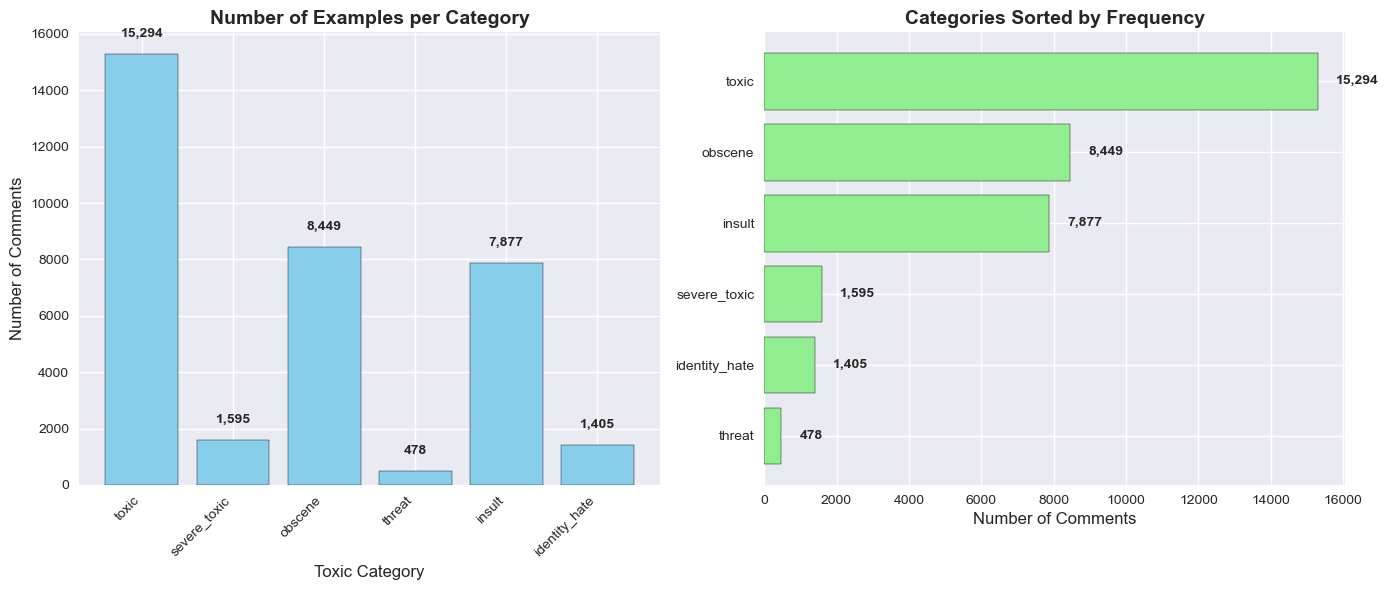

In [16]:
# Set style
plt.style.use('seaborn-v0_8')

# Calculate counts for each category
counts = train_df[toxic_columns].sum()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


bars1 = ax1.bar(range(len(counts)), counts.values, color='skyblue', edgecolor='black')
ax1.set_title('Number of Examples per Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Toxic Category', fontsize=12)
ax1.set_ylabel('Number of Comments', fontsize=12)
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=45, ha='right')

# Add count labels on top of bars
for i, (bar, count) in enumerate(zip(bars1, counts.values)):
    ax1.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# PLOT 2: Categories Sorted by Frequency
sorted_counts = counts.sort_values(ascending=True)
y_pos = range(len(sorted_counts))
bars2 = ax2.barh(y_pos, sorted_counts.values, color='lightgreen', edgecolor='black')
ax2.set_title('Categories Sorted by Frequency', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Comments', fontsize=12)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(sorted_counts.index)

# Add count labels on the right of bars
for i, (bar, count) in enumerate(zip(bars2, sorted_counts.values)):
    ax2.text(count + 500, i, f'{count:,}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

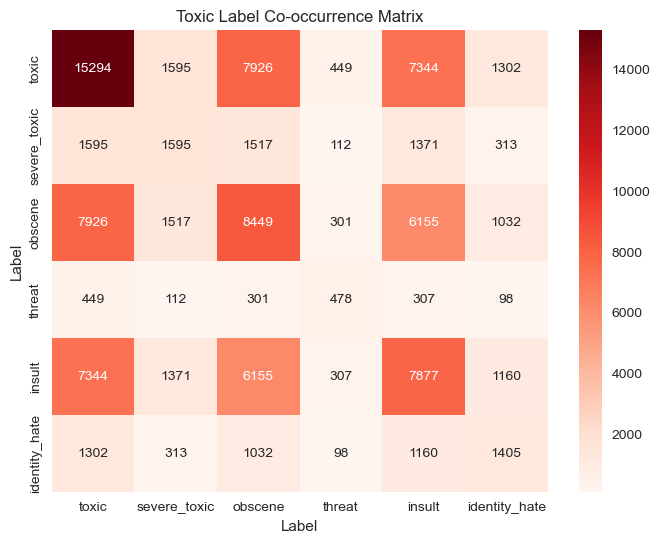

In [17]:
# Compute co-occurrence matrix
co_occurrence = train_df[toxic_columns].T.dot(train_df[toxic_columns])

plt.figure(figsize=(8,6))
sns.heatmap(
    co_occurrence,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Toxic Label Co-occurrence Matrix')
plt.xlabel('Label')
plt.ylabel('Label')
plt.show()

C:\Anaconda\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Anaconda\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

<Figure size 1000x600 with 0 Axes>

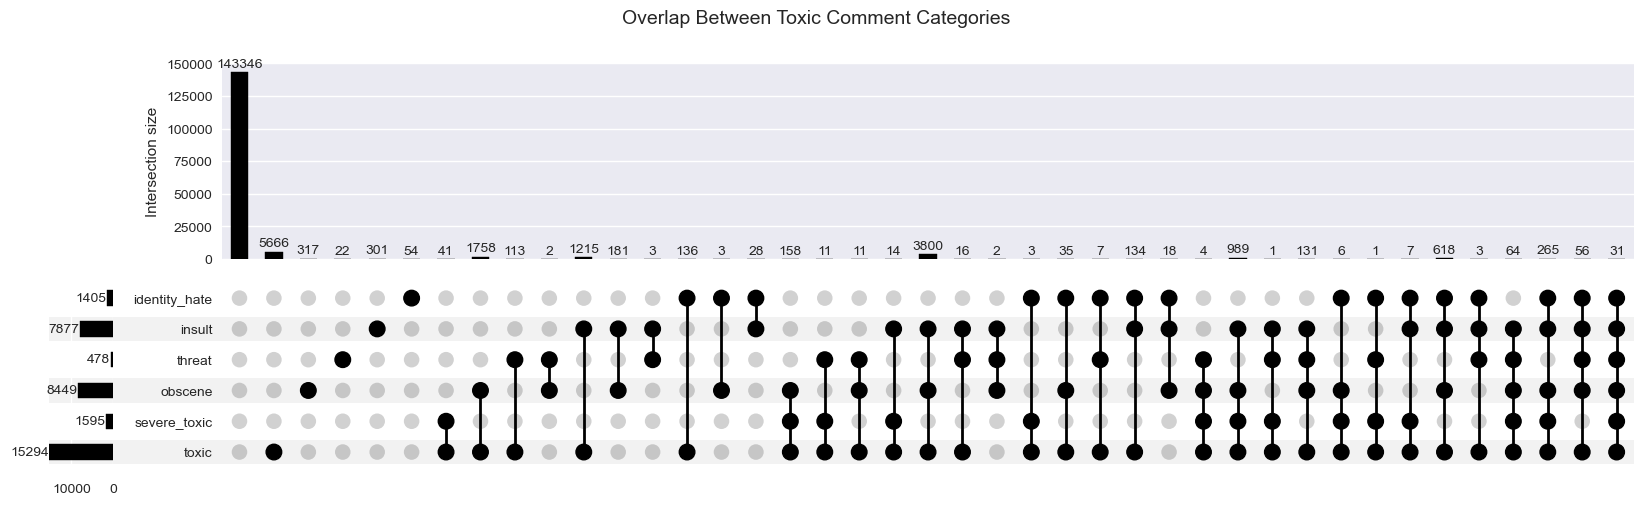

In [18]:
# Create boolean dataframe for toxic labels
label_df = train_df[toxic_columns].astype(bool)

# Convert to UpSet format
upset_data = from_indicators(toxic_columns, label_df)


plt.figure(figsize=(10,6))

UpSet(
    upset_data,
    show_counts=True,
    sort_categories_by=None
).plot()

plt.suptitle("Overlap Between Toxic Comment Categories", fontsize=14)
plt.show()

### Multi-Label Analysis

In [19]:
# MULTI-LABEL ANALYSIS
print("\n\n MULTI-LABEL ANALYSIS")
print("-" * 40)

# Count labels per toxic comment
toxic_comments = train_df[has_toxic].copy()
label_counts = toxic_comments[toxic_columns].sum(axis=1)

print(f"\n📊 How many labels do toxic comments have?")
for i in range(1, 7):
    count = (label_counts == i).sum()
    pct = (count / toxic_count) * 100 if toxic_count > 0 else 0
    if count > 0:
        print(f"  {i} label(s): {count:>6,} comments ({pct:5.1f}%)")



 MULTI-LABEL ANALYSIS
----------------------------------------

📊 How many labels do toxic comments have?
  1 label(s):  6,360 comments ( 39.2%)
  2 label(s):  3,480 comments ( 21.4%)
  3 label(s):  4,209 comments ( 25.9%)
  4 label(s):  1,760 comments ( 10.8%)
  5 label(s):    385 comments (  2.4%)
  6 label(s):     31 comments (  0.2%)


In [20]:
# Most common combinations
toxic_comments['label_combo'] = toxic_comments[toxic_columns].apply(
    lambda row: '+'.join([col for col, val in zip(toxic_columns, row) if val == 1]),
    axis=1
)
top_combos = toxic_comments['label_combo'].value_counts().head(5)

for combo, count in top_combos.items():
    print(f"  {combo:<30}: {count:>6,}")

  toxic                         :  5,666
  toxic+obscene+insult          :  3,800
  toxic+obscene                 :  1,758
  toxic+insult                  :  1,215
  toxic+severe_toxic+obscene+insult:    989


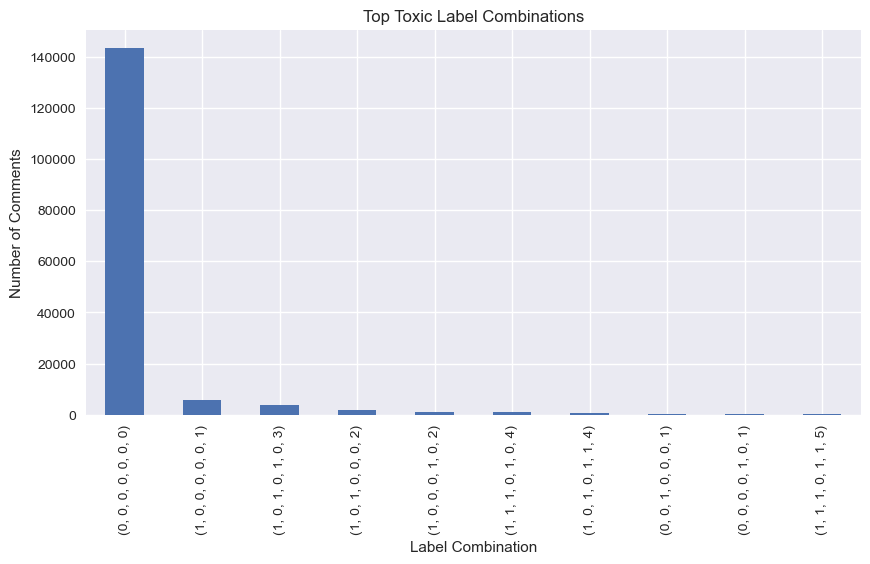

In [21]:
combo_counts = (
    train_df[toxic_columns]
    .assign(total=train_df[toxic_columns].sum(axis=1))
    .value_counts() # Count how many times each combination appears
    .head(10) # Take only the top 10 most frequent combinations
)

combo_counts.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Top Toxic Label Combinations")
plt.ylabel("Number of Comments")
plt.xlabel("Label Combination")
plt.show()

In [22]:
# check all labels have pure examples or not!
for category in toxic_columns:
    pure_exists = ((train_df[category] == 1) & (train_df[toxic_columns].sum(axis=1) == 1)).any()
    print(f"{category}: {'YES' if pure_exists else 'NO'}")

toxic: YES
severe_toxic: NO
obscene: YES
threat: YES
insult: YES
identity_hate: YES


### Key Insights Summary

In [23]:
# SUMMARY STATISTICS
print("\n\n KEY INSIGHTS")
print("-" * 40)
print(f" Dataset is HIGHLY IMBALANCED:")
print(f"   • {non_toxic_count/len(train_df)*100:.1f}% clean vs {toxic_count/len(train_df)*100:.1f}% toxic")
print(f"   • Model that always says 'non-toxic' would be {non_toxic_count/len(train_df)*100:.1f}% accurate!")
print(f"\n Most toxic comments have 1-2 labels:")
print(f"   • Average labels per toxic comment: {label_counts.mean():.2f}")
print(f"   • Most toxic: '{counts.idxmax()}' ({counts.max():,})")
print(f"   • Least toxic: '{counts.idxmin()}' ({counts.min():,})")
print(f"\n Threat is the rarest type:")
print(f"   • Only {counts['threat']:,} threat comments")
print(f"   • That's just {counts['threat']/len(train_df)*100:.2f}% of all comments")



 KEY INSIGHTS
----------------------------------------
 Dataset is HIGHLY IMBALANCED:
   • 89.8% clean vs 10.2% toxic
   • Model that always says 'non-toxic' would be 89.8% accurate!

 Most toxic comments have 1-2 labels:
   • Average labels per toxic comment: 2.16
   • Most toxic: 'toxic' (15,294)
   • Least toxic: 'threat' (478)

 Threat is the rarest type:
   • Only 478 threat comments
   • That's just 0.30% of all comments


In [24]:
# 1. NON-TOXIC
print("SELECT NON-TOXIC EXAMPLE:")
non_toxic_examples = train_df[train_df[toxic_columns].sum(axis=1) == 0]
non_toxic_count = len(non_toxic_examples)
print(f"Found {non_toxic_count:,} non-toxic examples")
print(f"Enter example number (1-{min(10, non_toxic_count)}): ")
choice = input()
if choice.isdigit() and 1 <= int(choice) <= min(10, non_toxic_count):
    chosen = non_toxic_examples.iloc[int(choice)-1]
    print(f"\n✓ SELECTED NON-TOXIC:")
    print(f"ID: {chosen['id']}")
    print(f"Text: {chosen['comment_text']}")
    print(f"All labels = 0")
    print(f"Length: {len(chosen['comment_text'])} chars")

SELECT NON-TOXIC EXAMPLE:
Found 143,346 non-toxic examples
Enter example number (1-10): 


 9



✓ SELECTED NON-TOXIC:
ID: 00040093b2687caa
Text: alignment on this subject and which are contrary to those of DuLithgow
All labels = 0
Length: 70 chars


In [25]:
# 2. TOXIC CATEGORIES
for category in toxic_columns:
    print(f"\n{'='*60}")
    print(f"SELECT {category.upper()} EXAMPLE:")
    
    # Try pure examples first
    pure_examples = train_df[(train_df[category] == 1) & (train_df[toxic_columns].sum(axis=1) == 1)]
    pure_count = len(pure_examples)
    
    if pure_count > 0:
        print(f"Found {pure_count} PURE examples (only {category}=1)")
        print(f"Enter example number (1-{pure_count}): ")
        choice = input()
        if choice.isdigit() and 1 <= int(choice) <= pure_count:
            chosen = pure_examples.iloc[int(choice)-1]
            print(f"\n✓ SELECTED PURE {category.upper()}:")
            print(f"ID: {chosen['id']}")
            print(f"Text: {chosen['comment_text']}")
            print(f"Label: {category}=1, others=0")
            print(f"Length: {len(chosen['comment_text'])} chars")
    else:
        # Fall back to mixed examples
        mixed_examples = train_df[train_df[category] == 1]
        mixed_count = len(mixed_examples)
        if mixed_count > 0:
            print(f"No pure examples. Found {mixed_count} MIXED examples with {category}=1")
            print(f"Enter example number (1-{mixed_count}): ")
            choice = input()
            if choice.isdigit() and 1 <= int(choice) <= mixed_count:
                chosen = mixed_examples.iloc[int(choice)-1]
                # Find other labels
                other_labels = [col for col in toxic_columns if col != category and chosen[col] == 1]
                print(f"\n✓ SELECTED MIXED {category.upper()}:")
                print(f"ID: {chosen['id']}")
                print(f"Text: {chosen['comment_text']}")
                print(f"Main label: {category}=1")
                if other_labels:
                    print(f"Also has: {', '.join(other_labels)}")
                print(f"Length: {len(chosen['comment_text'])} chars")
        else:
            print(f"No examples found for {category}")


SELECT TOXIC EXAMPLE:
Found 5666 PURE examples (only toxic=1)
Enter example number (1-5666): 


 3000



✓ SELECTED PURE TOXIC:
ID: de87cffffa98d230
Text: How differs a road-killed lawyer from a road-kill skunk?
Skid marks are before the skunk.
75.159.15.217
Label: toxic=1, others=0
Length: 103 chars

SELECT SEVERE_TOXIC EXAMPLE:
No pure examples. Found 1595 MIXED examples with severe_toxic=1
Enter example number (1-1595): 


 1200



✓ SELECTED MIXED SEVERE_TOXIC:
ID: 8185bd454c60a5bf
Text: FUCKASS  ople like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him... Thanks. I hate people like him.

...


✓ SELECTED PURE THREAT:
ID: e6cba0f00fc7475f
Text: "

New Award

Well Done!!!

  The IAmTheCoinMan You Are Really Annoying And You Are Good At Anti-Vandalism Barnstar I, , award you the The IAmTheCoinMan You Are Really Annoying And You Are Good At Anti-Vandalism Barnstar for your multiple prompt reverts to my joke.  Protecting the wiki isn't important, and an unimportant task under that is protecting other wikipedians!  Your efforts are much much not appreciated.  I hope someone cuts of your hands! "
Label: threat=1, others=0
Length: 454 chars

SELECT INSULT EXAMPLE:
Found 301 PURE examples (only insult=1)
Enter example number (1-301): 


 150



✓ SELECTED PURE INSULT:
ID: dd8e520576a9ba8b
Text: It's unfortunate that you are insulted but, your intentions are clear enough. I may not know you but, you are either lying or very stupid. Although you're not nearly as obvious Baseball Card Guy about it, both of you seem more concerned about each other than the articles themselves. Not answering my simple questions and your impatience are bearable but, lying (especially for such a silly thing) just isn't reasonable. Honestly, I'm not willing to do this if neither of you care. The only reason I'm involved is because this case was being neglected but, after that lie I've lost much of my good will.
Label: insult=1, others=0
Length: 603 chars

SELECT IDENTITY_HATE EXAMPLE:
Found 54 PURE examples (only identity_hate=1)
Enter example number (1-54): 


 30



✓ SELECTED PURE IDENTITY_HATE:
ID: dbbadd2bb0bfe7eb
Text: Jewish 

Please dont think that jews are everyone just based on your claims. Also dont think jews are smart. if you think so, you are making a clown out of yourself..
Label: identity_hate=1, others=0
Length: 166 chars


In [26]:
# Get all comments with multiple toxic labels
mixed_examples = train_df[train_df[toxic_columns].sum(axis=1) > 1]
mixed_count = len(mixed_examples)
print(f"Found {mixed_count:,} comments with multiple toxic labels")
print(f"Enter example number (1-{mixed_count}): ")
choice = input()
if choice.isdigit() and 1 <= int(choice) <= mixed_count:
    chosen = mixed_examples.iloc[int(choice)-1]
    print(f"\n✓ SELECTED MIXED EXAMPLE:")
    print(f"Comment ID: {chosen['id']}")
    print(f"\nLABELS:")
    for col in toxic_columns:
        print(f"  {col:15s}: {chosen[col]}")

    # Count how many 1's it has
    num_ones = sum([chosen[col] for col in toxic_columns])
    print(f"\nThis comment has {num_ones} toxic label(s)")
    
    # Show the text
    print(f"\nFULL TEXT:")
    print("-" * 80)
    print(chosen['comment_text'])
    print("-" * 80)
    print(f"Length: {len(chosen['comment_text'])} characters")

Found 9,865 comments with multiple toxic labels
Enter example number (1-9865): 


 4567



✓ SELECTED MIXED EXAMPLE:
Comment ID: c456d71ad00b67ce

LABELS:
  toxic          : 1
  severe_toxic   : 0
  obscene        : 1
  threat         : 0
  insult         : 0
  identity_hate  : 0

This comment has 2 toxic label(s)

FULL TEXT:
--------------------------------------------------------------------------------
But you don't have to be an ass about your diploma in Obscure Street Fighter Trivia. Oh wait, yes you do. You're a Wikipedia editor.76.10.75.168
--------------------------------------------------------------------------------
Length: 144 characters


### Problem Simplification: Multi-Label → Binary

In [27]:
# Create a new column 'is_toxic'
train_df['is_toxic'] = train_df[toxic_columns].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

# Check results
train_df[['comment_text', 'is_toxic']].head(10)

,comment_text,is_toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
5,"""\n\nCongratulations from me as well, use the ...",0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,Your vandalism to the Matt Shirvington article...,0
8,Sorry if the word 'nonsense' was offensive to ...,0
9,alignment on this subject and which are contra...,0


In [28]:
train_df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,is_toxic
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,0


In [29]:
# Check results
train_df[['comment_text', 'is_toxic']].head(10)

,comment_text,is_toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
5,"""\n\nCongratulations from me as well, use the ...",0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,Your vandalism to the Matt Shirvington article...,0
8,Sorry if the word 'nonsense' was offensive to ...,0
9,alignment on this subject and which are contra...,0


### Save Processed Data

In [30]:
train_df.to_csv("C:/01_Data/PythonProgram/Toxic_Comment_Classification_PROJECT/train_data/processed_train_step1.csv", index=False)